# 05 · RQ1 · Desempeño y la asimetría servicios/topología

**RQ1: ¿con qué precisión puede un pipeline multimodal recuperar una topología cloud
desde video?**

La respuesta corta es que depende mucho de qué se mida: **los servicios se recuperan bien
y la topología no**. Este notebook cuantifica esa asimetría sobre la muestra pareada de
321 videos y muestra que la causa principal tiene una forma concreta y medible:
**subdibujado de aristas**.

In [1]:
import json
from math import comb, sqrt
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.append("..")
from scripts.utils.effect_size import a12_ic, magnitud

RUNS = Path("../reports/runs")
PISO = Path("../reports/piso_ruido_panel30.json")
pd.set_option("display.width", 200)

S = pd.read_csv(RUNS / "2026-08-20_standard_v6corrected_370v/results.csv")
P = pd.read_csv(RUNS / "2026-08-21_parsimonious_v9/results.csv")

m = S.merge(P, on="video_id", suffixes=("_s", "_p"))
D = m[(m.graph_usable_s == True) & (m.graph_usable_p == True)].copy()
MDE = {k: v["mde_30"] for k, v in json.loads(PISO.read_text(encoding="utf-8"))["metricas"].items()}

print(f"muestra pareada: n = {len(D)}")
print("Las columnas *_f1 del CSV ya vienen en escala 0-100.")

muestra pareada: n = 321
Las columnas *_f1 del CSV ya vienen en escala 0-100.


## 1 · La asimetría

Misma arquitectura, mismo video, mismo evaluador: lo único que cambia es **qué se puntúa**.

,Standard,Parsimonious,brecha
Service F1,86.78,85.73,1.05
Edge F1,59.65,57.01,2.64



Asimetria dentro de Standard    : 27.13 puntos
Asimetria dentro de Parsimonious: 28.72 puntos


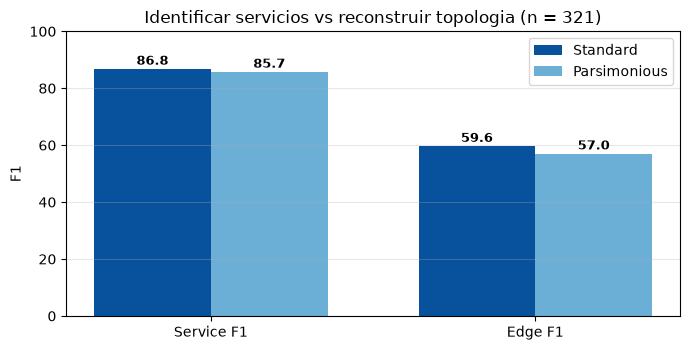

In [2]:
asim = pd.DataFrame({
    "Standard":     [D.svc_f1_s.mean(), D.edge_f1_s.mean()],
    "Parsimonious": [D.svc_f1_p.mean(), D.edge_f1_p.mean()],
}, index=["Service F1", "Edge F1"])
asim["brecha"] = asim["Standard"] - asim["Parsimonious"]
display(asim.round(2))

print(f"\nAsimetria dentro de Standard    : {D.svc_f1_s.mean() - D.edge_f1_s.mean():.2f} puntos")
print(f"Asimetria dentro de Parsimonious: {D.svc_f1_p.mean() - D.edge_f1_p.mean():.2f} puntos")

fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(2); w = .36
ax.bar(x - w/2, asim["Standard"], w, label="Standard", color="#08519c")
ax.bar(x + w/2, asim["Parsimonious"], w, label="Parsimonious", color="#6baed6")
for i, (a, b) in enumerate(zip(asim["Standard"], asim["Parsimonious"])):
    ax.text(i - w/2, a + 1.5, f"{a:.1f}", ha="center", fontsize=9, fontweight="bold")
    ax.text(i + w/2, b + 1.5, f"{b:.1f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(asim.index); ax.set_ylim(0, 100)
ax.set_ylabel("F1"); ax.legend(); ax.grid(alpha=.3, axis="y")
ax.set_title(f"Identificar servicios vs reconstruir topologia (n = {len(D)})")
plt.tight_layout(); plt.show()

Cerca de **27 puntos** separan las dos métricas en los dos pipelines. No es un detalle de
un diseño de prompt: es una propiedad del problema.

## 2 · Precision y recall: dónde se rompe

Descomponer el F1 dice **cómo** falla, no solo cuánto.

In [3]:
desc = pd.DataFrame({
    "Service P":  [D.svc_precision_s.mean(),  D.svc_precision_p.mean()],
    "Service R":  [D.svc_recall_s.mean(),     D.svc_recall_p.mean()],
    "Edge P":     [D.edge_precision_s.mean(), D.edge_precision_p.mean()],
    "Edge R":     [D.edge_recall_s.mean(),    D.edge_recall_p.mean()],
}, index=["Standard", "Parsimonious"]).T
display(desc.round(2))

print("\nEn aristas la precision supera claramente al recall en los dos pipelines:")
for tag, p, r in (("Standard", D.edge_precision_s.mean(), D.edge_recall_s.mean()),
                  ("Parsimonious", D.edge_precision_p.mean(), D.edge_recall_p.mean())):
    print(f"  {tag:<14} P = {p:.2f}   R = {r:.2f}   P - R = {p - r:+.2f}")
print("\nLo que produce tiende a ser correcto; el problema es lo que NO produce.")

,Standard,Parsimonious
Service P,88.61,85.82
Service R,85.70,86.21
Edge P,70.36,68.27
Edge R,53.99,51.44



En aristas la precision supera claramente al recall en los dos pipelines:
  Standard       P = 70.36   R = 53.99   P - R = +16.37
  Parsimonious   P = 68.27   R = 51.44   P - R = +16.83

Lo que produce tiende a ser correcto; el problema es lo que NO produce.


## 3 · Subdibujado: el sistema dibuja menos aristas de las que hay

La hipótesis que sigue del punto anterior: si el recall de aristas es bajo pero la
precisión no, el modelo debería estar emitiendo **menos aristas** que el ground truth. Se
verifica directamente contando.

,generadas Standard,generadas Parsimonious,ground truth,ratio S/GT
nodos,9.15,9.33,9.11,1.01
aristas,9.04,8.83,12.42,0.73



diferencia media por video (Standard - GT):
  nodos   : +0.05   (MDE 0.34)  -> dentro del ruido
  aristas : -3.38   (MDE 0.73)  -> SENAL


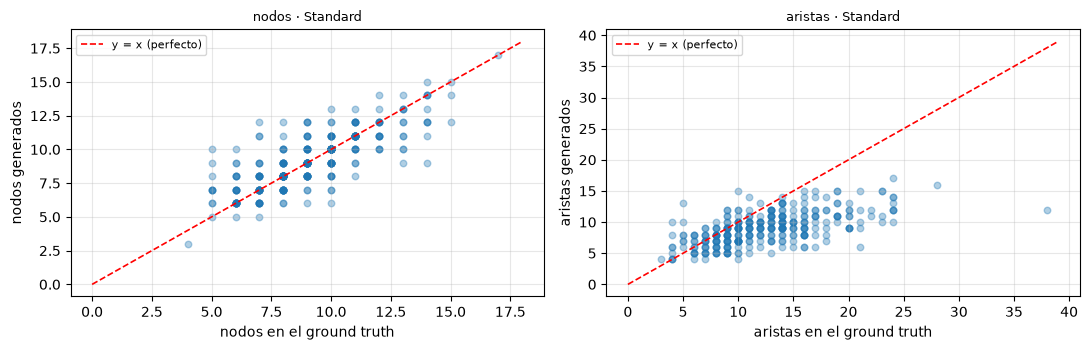

In [4]:
cnt = pd.DataFrame({
    "generadas Standard":     [D.gen_nodes_s.mean(), D.gen_edges_s.mean()],
    "generadas Parsimonious": [D.gen_nodes_p.mean(), D.gen_edges_p.mean()],
    "ground truth":           [D.gt_nodes_s.mean(),  D.gt_edges_s.mean()],
}, index=["nodos", "aristas"])
cnt["ratio S/GT"] = [cnt.loc["nodos", "generadas Standard"] / cnt.loc["nodos", "ground truth"],
                     cnt.loc["aristas", "generadas Standard"] / cnt.loc["aristas", "ground truth"]]
display(cnt.round(2))

d_nodos   = D.gen_nodes_s - D.gt_nodes_s
d_aristas = D.gen_edges_s - D.gt_edges_s
print(f"\ndiferencia media por video (Standard - GT):")
print(f"  nodos   : {d_nodos.mean():+.2f}   (MDE {MDE['nodos generados']:.2f})  "
      f"-> {'SENAL' if abs(d_nodos.mean()) > MDE['nodos generados'] else 'dentro del ruido'}")
print(f"  aristas : {d_aristas.mean():+.2f}   (MDE {MDE['aristas generadas']:.2f})  "
      f"-> {'SENAL' if abs(d_aristas.mean()) > MDE['aristas generadas'] else 'dentro del ruido'}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (gen, gtc, tit) in zip(axes, [(D.gen_nodes_s, D.gt_nodes_s, "nodos"),
                                      (D.gen_edges_s, D.gt_edges_s, "aristas")]):
    lim = max(gen.max(), gtc.max()) + 1
    ax.scatter(gtc, gen, alpha=.35, s=22)
    ax.plot([0, lim], [0, lim], ls="--", c="red", lw=1.2, label="y = x (perfecto)")
    ax.set_xlabel(f"{tit} en el ground truth"); ax.set_ylabel(f"{tit} generados")
    ax.set_title(f"{tit} · Standard", fontsize=9); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Los nodos caen sobre la diagonal; las aristas caen sistemáticamente por debajo.**

El sistema identifica aproximadamente la cantidad correcta de servicios y después los
conecta de menos. El déficit de aristas supera holgadamente el MDE del conteo, así que no
es ruido: es un sesgo direccional del sistema. La causa se descompone en el notebook 07.

## 4 · Comparación pareada Standard vs Parsimonious

Los dos brazos difieren en arquitectura, no solo en prompt (Standard: 2 llamadas con
esquema forzado y 5 reintentos; Parsimonious: 1 llamada con JSON parseado a mano y sin
reintentos). Ese confound se declara: **no es una comparación de prompts**.

In [5]:
def sign_test(g: int, p: int) -> float:
    n = g + p
    if n == 0:
        return 1.0
    k = min(g, p)
    return min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n)

filas = []
for metrica, cs, cp in (("Service F1", "svc_f1_s", "svc_f1_p"),
                        ("Edge F1",    "edge_f1_s", "edge_f1_p")):
    dif = D[cp] - D[cs]                      # Parsimonious - Standard
    g = int((dif > 1e-9).sum()); p = int((dif < -1e-9).sum()); e = len(dif) - g - p
    sd = dif.std(ddof=1); ic = 1.96 * sd / sqrt(len(dif))
    filas.append({"metrica": metrica, "Standard": D[cs].mean(), "Parsimonious": D[cp].mean(),
                  "delta (P-S)": dif.mean(), "IC95 +-": ic,
                  "gana P": g, "gana S": p, "empata": e, "p (signos)": sign_test(g, p)})
comp = pd.DataFrame(filas).set_index("metrica")
display(comp.round(4))

,Standard,Parsimonious,delta (P-S),IC95 +-,gana P,gana S,empata,p (signos)
metrica,,,,,,,,
Service F1,86.7796,85.7278,-1.0518,0.9009,68,94,159,0.0492
Edge F1,59.6483,57.0092,-2.6391,1.5156,90,147,84,0.0003


En **servicios** hay muchísimos empates y el p queda en el borde: la diferencia **no queda
establecida**. En **aristas** gana Standard con un intervalo que no toca el cero.

La afirmación defendible es **partida**: *"Parsimonious rinde igual a la mitad del costo"*
vale para servicios y **no** vale para topología.

> El detalle completo, con Wilcoxon además del test de signos, está en
> [`evidence/table1_parsimonious_vs_standard.md`](../evidence/table1_parsimonious_vs_standard.md).

### El tamaño de efecto, que es lo que decide si la diferencia importa

Un p-valor dice si la diferencia es distinguible del azar; no dice si es grande. Arcuri
y Briand insisten en reportar las dos cosas, y recomiendan **Â₁₂ de Vargha y Delaney**
para escala de intervalo —descartando la familia de la *d* de Cohen, que asume
normalidad que estas distribuciones no tienen—.

Â₁₂ es la probabilidad de que un video tomado al azar puntúe mejor con un brazo que con
el otro, contando empates como medio. **0.5 es ausencia de efecto**; 0.56 / 0.64 / 0.71
son los umbrales de magnitud pequeña, mediana y grande.

In [6]:
filas = []
for metrica, cs, cp in (("Service F1", "svc_f1_s", "svc_f1_p"),
                        ("Edge F1",    "edge_f1_s", "edge_f1_p")):
    # El bootstrap remuestrea videos completos: el diseño es pareado y remuestrear cada
    # brazo por separado rompería el apareamiento e inflaría el intervalo.
    a, (lo, hi) = a12_ic(D[cs], D[cp], n_boot=10000, seed=0)
    filas.append({"métrica": metrica,
                  "Â₁₂ (Standard > Parsimonious)": a,
                  "IC 95%": f"[{lo:.3f}, {hi:.3f}]",
                  "magnitud": magnitud(a),
                  "IC incluye 0.5": lo <= 0.5 <= hi})
display(pd.DataFrame(filas).set_index("métrica").round(3))

print("Las dos magnitudes son insignificantes. En servicios el IC incluye 0.5, asi que\n"
      "no hay efecto establecido; en aristas lo excluye, pero Â₁₂ = 0.536 significa que\n"
      "Standard gana en el 53.6 % de los videos: detectable y practicamente irrelevante.\n"
      "Es exactamente el caso que Arcuri advierte cuando se reporta un p sin tamaño de\n"
      "efecto — y el que sostiene que la afirmacion de RQ1 sea partida y no una paridad.")

,Â₁₂ (Standard > Parsimonious),IC 95%,magnitud,IC incluye 0.5
métrica,,,,
Service F1,0.524,"[0.499, 0.549]",insignificante,True
Edge F1,0.536,"[0.513, 0.559]",insignificante,False


Las dos magnitudes son insignificantes. En servicios el IC incluye 0.5, asi que
no hay efecto establecido; en aristas lo excluye, pero Â₁₂ = 0.536 significa que
Standard gana en el 53.6 % de los videos: detectable y practicamente irrelevante.
Es exactamente el caso que Arcuri advierte cuando se reporta un p sin tamaño de
efecto — y el que sostiene que la afirmacion de RQ1 sea partida y no una paridad.


In [7]:
OUT = Path("../reports/rq1_desempeno.json")
OUT.write_text(json.dumps({
    "generado_por": "notebooks/05_rq1_desempeno.ipynb",
    "n_pareados": len(D),
    "medias": {"standard": {"svc_f1": round(D.svc_f1_s.mean(), 2), "edge_f1": round(D.edge_f1_s.mean(), 2)},
               "parsimonious": {"svc_f1": round(D.svc_f1_p.mean(), 2), "edge_f1": round(D.edge_f1_p.mean(), 2)}},
    "asimetria_svc_menos_edge": {"standard": round(D.svc_f1_s.mean() - D.edge_f1_s.mean(), 2),
                                 "parsimonious": round(D.svc_f1_p.mean() - D.edge_f1_p.mean(), 2)},
    "conteos": {"gen_nodos_s": round(D.gen_nodes_s.mean(), 2), "gen_aristas_s": round(D.gen_edges_s.mean(), 2),
                "gen_nodos_p": round(D.gen_nodes_p.mean(), 2), "gen_aristas_p": round(D.gen_edges_p.mean(), 2),
                "gt_nodos": round(D.gt_nodes_s.mean(), 2), "gt_aristas": round(D.gt_edges_s.mean(), 2)},
    "subdibujado_aristas_por_video": round((D.gen_edges_s - D.gt_edges_s).mean(), 2),
    "comparacion_pareada": comp.round(6).reset_index().to_dict(orient="records"),
}, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"escrito -> {OUT}")

escrito -> ../reports/rq1_desempeno.json


## Para el paper

1. **Asimetría de ~27 puntos** entre identificar servicios y reconstruir topología, estable
   en los dos pipelines.
2. En aristas, **precisión > recall**: lo que se emite suele estar bien; falta lo que no se
   emite.
3. **Subdibujado medible**: ~9 aristas generadas contra ~12.4 del ground truth, con los
   nodos calzando bien. El déficit supera el MDE del conteo.
4. La comparación entre los dos brazos es **partida** y arrastra un confound de
   arquitectura que hay que declarar.